<a href="https://colab.research.google.com/github/sirfabhijeet/agriculture-field-segmentation-unet-/blob/main/cv_in_agriculture_(unet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q rasterio shapely opencv-python segmentation-models-pytorch albumentations tifffile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os
import json
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window

from shapely.geometry import Polygon
from shapely.geometry import MultiPolygon
from shapely.geometry import box

import tifffile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/12CYZ4HRE Wu Jing.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
!find /content/dataset -maxdepth 3

/content/dataset
/content/dataset/imagery
/content/dataset/imagery/nir.tif
/content/dataset/imagery/blue.tif
/content/dataset/imagery/green.tif
/content/dataset/imagery/red.tif
/content/dataset/boundary.json


In [ ]:
DATASET = "/content/dataset"

IMAGE_DIR = os.path.join(DATASET, "imagery")

BOUNDARY = os.path.join(DATASET, "boundary.json")

In [ ]:
red_ds = rasterio.open(f"{IMAGE_DIR}/red.tif")
green_ds = rasterio.open(f"{IMAGE_DIR}/green.tif")
blue_ds = rasterio.open(f"{IMAGE_DIR}/blue.tif")
nir_ds = rasterio.open(f"{IMAGE_DIR}/nir.tif")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [ ]:
HEIGHT = red_ds.height
WIDTH = red_ds.width

print("Height :", HEIGHT)
print("Width  :", WIDTH)

Height : 16836
Width  : 13405


In [ ]:
print(red_ds.count)
print(green_ds.count)
print(blue_ds.count)
print(nir_ds.count)

1
1
1
1


In [ ]:
with open(BOUNDARY, "r") as f:

    geojson = json.load(f)

print(type(geojson))

print(geojson.keys())

<class 'dict'>
dict_keys(['type', 'coordinates'])


In [ ]:
print(geojson["type"])

MultiPolygon


In [ ]:
polygons = []

for multipolygon in geojson["coordinates"]:

    for polygon in multipolygon:

        polygons.append(
            Polygon(polygon)
        )

field = MultiPolygon(polygons)

print("Total polygons :", len(polygons))

Total polygons : 2


In [ ]:
print("Image Width :", WIDTH)

print("Image Height :", HEIGHT)

print("Total Pixels :", WIDTH * HEIGHT)

print("Number of Polygons :", len(polygons))

Image Width : 13405
Image Height : 16836
Total Pixels : 225686580
Number of Polygons : 2


In [ ]:
print("Polygon Valid :", field.is_valid)

print("Polygon Area :", field.area)

print("Polygon Bounds :", field.bounds)

Polygon Valid : True
Polygon Area : 76481718.0
Polygon Bounds : (824.0, 675.0, 12580.0, 16160.0)


In [ ]:
PATCH_DIR = "/content/agri_patches"

IMAGE_PATCH_DIR = os.path.join(PATCH_DIR, "images")
MASK_PATCH_DIR = os.path.join(PATCH_DIR, "masks")

os.makedirs(IMAGE_PATCH_DIR, exist_ok=True)
os.makedirs(MASK_PATCH_DIR, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [ ]:
PATCH_SIZE = 256
STRIDE = 256

patch_id = 0

In [ ]:
def read_patch(x, y):

    window = Window(
        x,
        y,
        PATCH_SIZE,
        PATCH_SIZE
    )

    red = red_ds.read(1, window=window)
    green = green_ds.read(1, window=window)
    blue = blue_ds.read(1, window=window)
    nir = nir_ds.read(1, window=window)

    image = np.stack(
        [red, green, blue, nir],
        axis=-1
    )

    return image

In [ ]:
from shapely.geometry import Polygon
import cv2

def create_patch_mask(x, y):

    mask = np.zeros(
        (PATCH_SIZE, PATCH_SIZE),
        dtype=np.uint8
    )

    patch_box = box(
        x,
        y,
        x + PATCH_SIZE,
        y + PATCH_SIZE
    )

    for poly in polygons:

        if not poly.intersects(patch_box):
            continue

        inter = poly.intersection(patch_box)

        if inter.is_empty:
            continue

        if inter.geom_type == "Polygon":

            coords = np.array(inter.exterior.coords)

            coords[:,0] -= x
            coords[:,1] -= y

            cv2.fillPoly(
                mask,
                [coords.astype(np.int32)],
                1
            )

        elif inter.geom_type == "MultiPolygon":

            for p in inter.geoms:

                coords = np.array(p.exterior.coords)

                coords[:,0] -= x
                coords[:,1] -= y

                cv2.fillPoly(
                    mask,
                    [coords.astype(np.int32)],
                    1
                )

    return mask

In [ ]:
x = 5000
y = 5000

image = read_patch(x, y)
mask = create_patch_mask(x, y)

print(image.shape)
print(mask.shape)

print(np.unique(mask))
print(mask.sum())

(256, 256, 4)
(256, 256)
[1]
65536


In [ ]:
found = False

for y in range(0, HEIGHT - PATCH_SIZE, STRIDE):

    for x in range(0, WIDTH - PATCH_SIZE, STRIDE):

        mask = create_patch_mask(x, y)

        if mask.sum() > 100:

            print("Foreground patch found!")

            print("X =", x)

            print("Y =", y)

            found = True

            break

    if found:
        break

Foreground patch found!
X = 1280
Y = 512


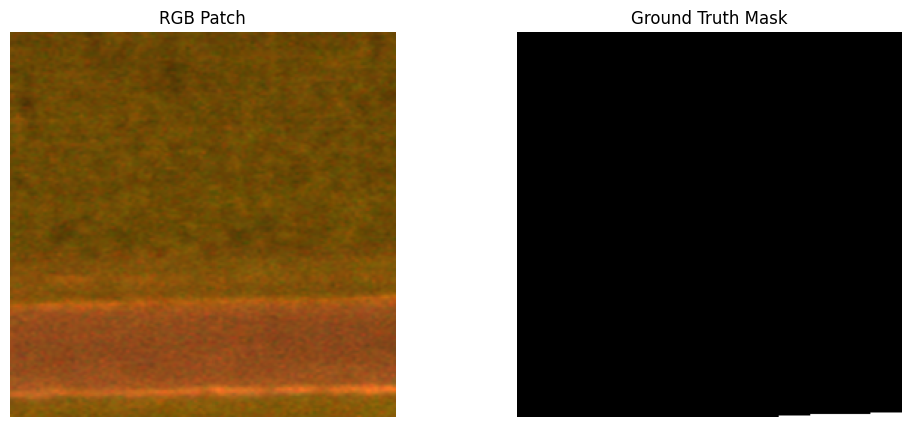

In [ ]:
image = read_patch(x, y)
mask = create_patch_mask(x, y)

rgb = image[:,:,:3].astype(np.float32)

rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-8)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(rgb)
plt.title("RGB Patch")
plt.axis("off")

plt.subplot(122)
plt.imshow(mask, cmap="gray", vmin=0, vmax=1)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [ ]:
patch_id = 0

saved_foreground = 0

for y in range(0, HEIGHT - PATCH_SIZE + 1, STRIDE):

    for x in range(0, WIDTH - PATCH_SIZE + 1, STRIDE):

        image = read_patch(x, y)
        mask = create_patch_mask(x, y)

        foreground_ratio = np.mean(mask)

        # Skip patches with almost no foreground
        if foreground_ratio < 0.05:
            continue
        if foreground_ratio > 0.95:
            continue

        np.save(
            os.path.join(
                IMAGE_PATCH_DIR,
                f"{patch_id}.npy"
            ),
            image
        )

        np.save(
            os.path.join(
                MASK_PATCH_DIR,
                f"{patch_id}.npy"
            ),
            mask
        )

        patch_id += 1
        saved_foreground += 1

print("=" * 50)
print("Total Saved Patches :", patch_id)
print("=" * 50)

Total Saved Patches : 210


In [ ]:
ratios = []

for mask_name in sorted(os.listdir(MASK_PATCH_DIR)):

    mask = np.load(os.path.join(MASK_PATCH_DIR, mask_name))

    ratios.append(np.mean(mask))

ratios = np.array(ratios)

print("Minimum :", ratios.min())
print("Maximum :", ratios.max())

print("Average :", ratios.mean())

print("All foreground :", np.sum(ratios == 1.0))

print("All background :", np.sum(ratios == 0.0))

Minimum : 0.0515594482421875
Maximum : 0.9453125
Average : 0.501325189499628
All foreground : 0
All background : 0


In [ ]:
image_files = sorted(os.listdir(IMAGE_PATCH_DIR))
mask_files = sorted(os.listdir(MASK_PATCH_DIR))

print("Image patches :", len(image_files))
print("Mask patches  :", len(mask_files))

assert len(image_files) == len(mask_files)

Image patches : 210
Mask patches  : 210


Image Shape : (256, 256, 4)
Mask Shape  : (256, 256)
Mask Unique : [0 1]
Foreground Pixels : 46720


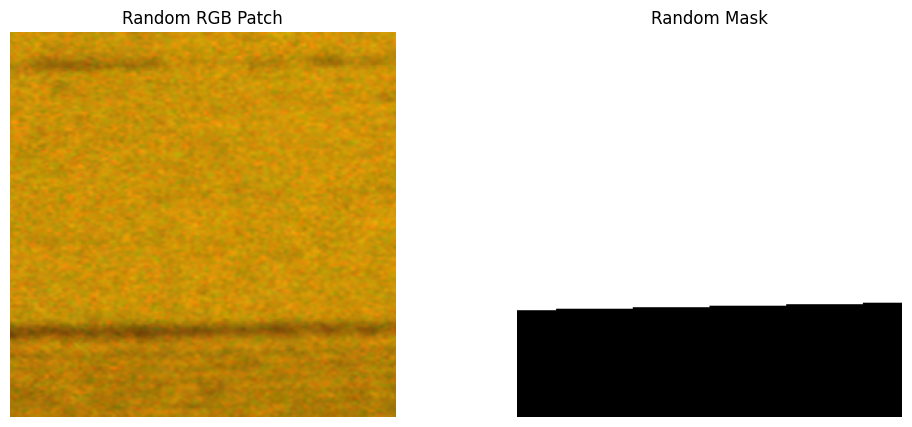

In [ ]:
idx = random.randint(0, len(image_files)-1)

image = np.load(os.path.join(IMAGE_PATCH_DIR, image_files[idx]))
mask = np.load(os.path.join(MASK_PATCH_DIR, mask_files[idx]))

print("Image Shape :", image.shape)
print("Mask Shape  :", mask.shape)
print("Mask Unique :", np.unique(mask))
print("Foreground Pixels :", np.sum(mask))

rgb = image[:,:,:3].astype(np.float32)
rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-8)

plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(rgb)
plt.title("Random RGB Patch")
plt.axis("off")

plt.subplot(122)
plt.imshow(mask, cmap="gray", vmin=0, vmax=1)
plt.title("Random Mask")
plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

image_files = sorted(os.listdir(IMAGE_PATCH_DIR))
mask_files = sorted(os.listdir(MASK_PATCH_DIR))

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_files,
    mask_files,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Images :", len(train_imgs))
print("Validation Images :", len(val_imgs))

Training Images : 168
Validation Images : 42


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
from torch.utils.data import Dataset

class AgricultureDataset(Dataset):

    def __init__(self,
                 image_list,
                 mask_list,
                 image_dir,
                 mask_dir,
                 transform=None):

        self.image_list = image_list
        self.mask_list = mask_list
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):

        image = np.load(
            os.path.join(self.image_dir,
                         self.image_list[idx])
        ).astype(np.float32)

        mask = np.load(
            os.path.join(self.mask_dir,
                         self.mask_list[idx])
        ).astype(np.float32)

        mask = np.expand_dims(mask, axis=-1)

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        if mask.ndim == 3:
          mask = mask.permute(2,0,1)
          mask = mask.float()




        return image, mask

In [ ]:
train_dataset = AgricultureDataset(
    train_imgs,
    train_masks,
    IMAGE_PATCH_DIR,
    MASK_PATCH_DIR,
    train_transform
)

val_dataset = AgricultureDataset(
    val_imgs,
    val_masks,
    IMAGE_PATCH_DIR,
    MASK_PATCH_DIR,
    val_transform
)

In [ ]:
image, mask = train_dataset[0]

print(image.shape)
print(mask.shape)

print(image.dtype)
print(mask.dtype)

print(mask.min(), mask.max())

torch.Size([4, 256, 256])
torch.Size([1, 256, 256])
torch.float32
torch.float32
tensor(0.) tensor(1.)


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 4, 256, 256])
torch.Size([8, 1, 256, 256])


In [ ]:
import torch
import torch.nn as nn

import segmentation_models_pytorch as smp

from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1,
    activation=None
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
model = model.to(device)

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
dummy = torch.randn(2,4,256,256).to(device)

output = model(dummy)

print(output.shape)

torch.Size([2, 1, 256, 256])


In [ ]:
dice_loss = smp.losses.DiceLoss(
    mode="binary"
)

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

In [ ]:
def criterion(pred, target):

    loss1 = dice_loss(pred, target)

    loss2 = bce_loss(pred, target)

    return loss1 + loss2

In [ ]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=30

)

In [ ]:
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_589/2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
epochs = 30

best_loss = float("inf")

train_losses = []

val_losses = []

In [ ]:
print(model)

print()

print(device)

print()

print(optimizer)

print()

print(scheduler)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):

    model.train()

    running_loss = 0.0

    loop = tqdm(loader)

    for images, masks in loop:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [ ]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
best_loss = float("inf")

patience = 7
counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler
    )

    val_loss = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_deeplabv3plus.pth"
        )

        print("✅ Best model saved")

        counter = 0

    else:

        counter += 1

        print(f"EarlyStopping Counter : {counter}")

    if counter >= patience:

        print("Early stopping activated")

        break


Epoch 1/30


  0%|          | 0/21 [00:00<?, ?it/s]/tmp/ipykernel_589/2193604494.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 21/21 [00:04<00:00,  5.06it/s, loss=0.792]


Train Loss : 1.0250
Validation Loss : 0.7760
✅ Best model saved

Epoch 2/30


100%|██████████| 21/21 [00:01<00:00, 11.54it/s, loss=0.708]


Train Loss : 0.7258
Validation Loss : 0.5256
✅ Best model saved

Epoch 3/30


...

Train Loss : 0.1942
Validation Loss : 0.1645
EarlyStopping Counter : 1

Epoch 29/30


100%|██████████| 21/21 [00:01<00:00, 11.51it/s, loss=0.212]


Train Loss : 0.2067
Validation Loss : 0.1615
✅ Best model saved

Epoch 30/30


100%|██████████| 21/21 [00:01<00:00, 11.30it/s, loss=0.436]


Train Loss : 0.1989
Validation Loss : 0.1641
EarlyStopping Counter : 1


In [ ]:
model.load_state_dict(torch.load("best_deeplabv3plus.pth"))

model.eval()

print("Best model loaded.")

Best model loaded.


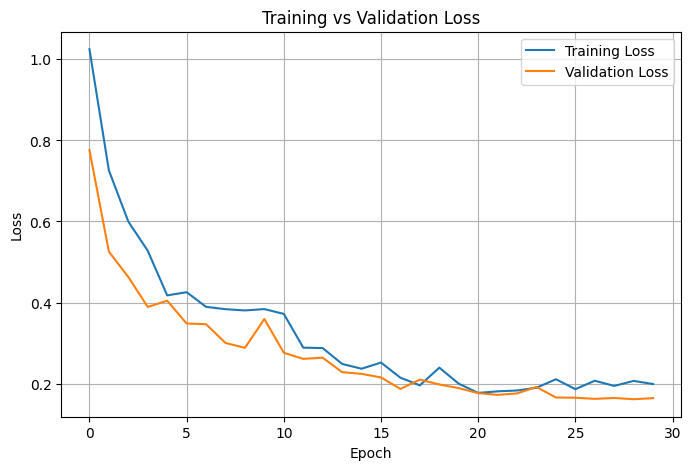

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import torch

def dice_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

In [ ]:
def iou_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    return (intersection + smooth) / (union + smooth)

In [ ]:
model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        dice_scores.append(
            dice_score(outputs, masks).item()
        )

        iou_scores.append(
            iou_score(outputs, masks).item()
        )

print("Average Dice :", np.mean(dice_scores))
print("Average IoU :", np.mean(iou_scores))

Average Dice : 0.9672983722253279
Average IoU : 0.9371709281747992


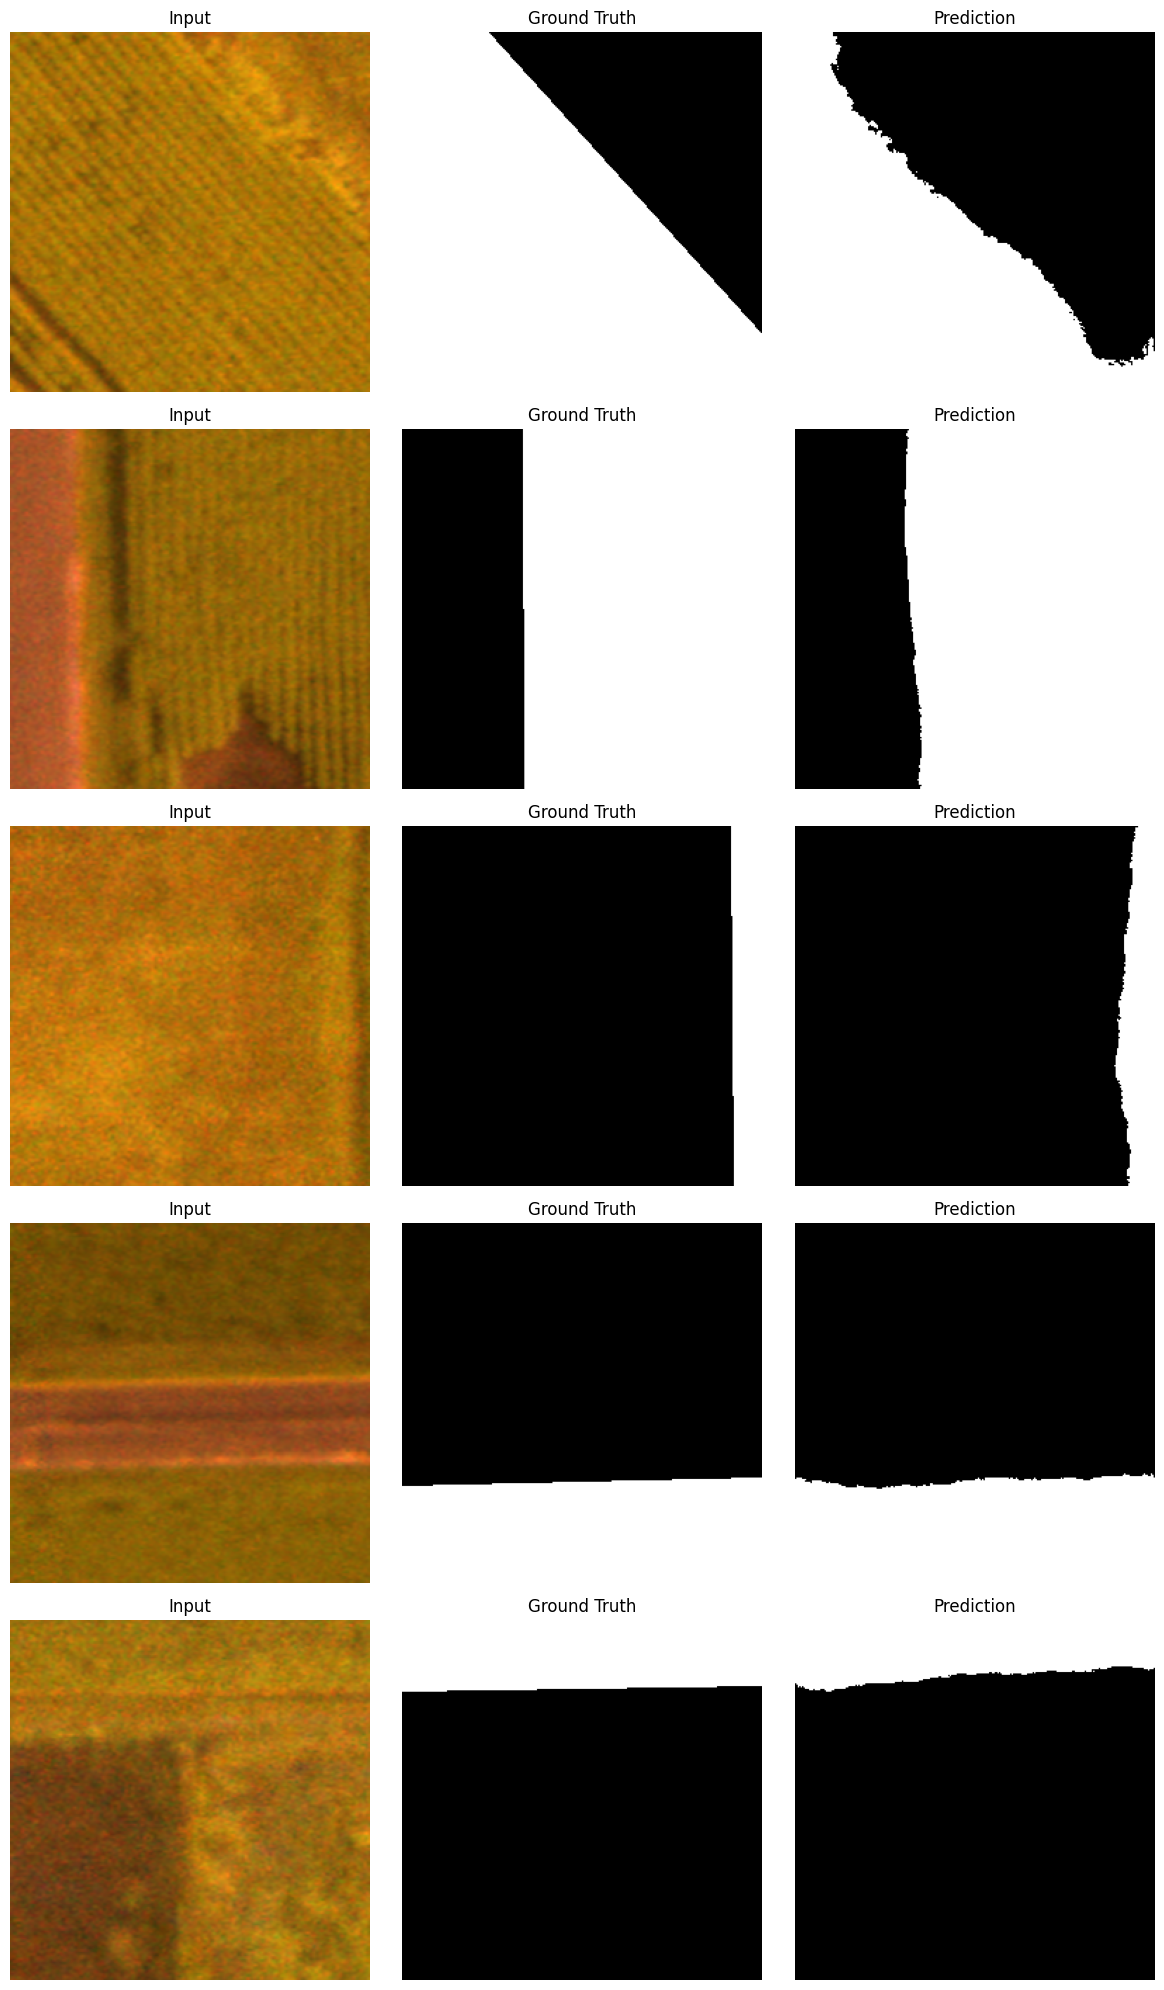

In [ ]:
model.eval()

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

with torch.no_grad():

    for i in range(5):

        image, mask = val_dataset[i]

        input_tensor = image.unsqueeze(0).to(device)

        pred = model(input_tensor)

        pred = torch.sigmoid(pred)

        pred = (pred > 0.5).float()

        rgb = image[:3].permute(1,2,0).numpy()

        rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-8)

        axes[i,0].imshow(rgb)
        axes[i,0].set_title("Input")
        axes[i,0].axis("off")

        axes[i,1].imshow(mask.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[i,1].set_title("Ground Truth")
        axes[i,1].axis("off")

        axes[i,2].imshow(pred.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        axes[i,2].set_title("Prediction")
        axes[i,2].axis("off")

plt.tight_layout()
plt.show()

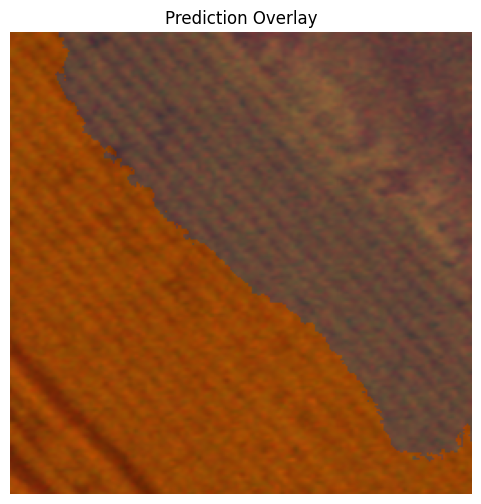

In [ ]:
image, mask = val_dataset[0]

model.eval()

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device))

pred = torch.sigmoid(pred)
pred = (pred > 0.5).float().cpu().numpy().squeeze()

rgb = image[:3].permute(1,2,0).numpy()
rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-8)

plt.figure(figsize=(6,6))

plt.imshow(rgb)
plt.imshow(pred, alpha=0.4, cmap="jet")

plt.title("Prediction Overlay")

plt.axis("off")

plt.show()